# 01 — Khám phá Dataset GaitPDB

**Mục tiêu notebook này:**
1. Hiểu cấu trúc thực tế của file `.txt` trong GaitPDB
2. **Xác nhận column mapping** dùng trong `preprocess.py::aggregate_gaitpdb_columns()`
3. So sánh pattern lực bàn chân giữa bệnh nhân PD và người bình thường
4. Phát hiện file bị lỗi hoặc thiếu dữ liệu trước khi chạy `preprocess.py`

**Yêu cầu trước khi chạy:**
- Tải dataset từ https://physionet.org/content/gaitpdb/1.0.0/
- Giải nén vào `ml/data/raw/gaitpdb/`
- Cấu trúc mong đợi:
```
ml/data/raw/gaitpdb/
├── GaXXXXXX.txt   ← bệnh nhân Parkinson (Ga = Gait abnormal)
├── CoXXXXXX.txt   ← người bình thường   (Co = Control)
├── demographics.txt
├── format.txt
└── ...
```

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt

warnings.filterwarnings('ignore')

# Chạy notebook từ thư mục gốc Smart Insole/
# Nếu chạy từ ml/notebooks/ thì đổi thành Path('../../')
ROOT = Path('../../')
DATA_DIR = ROOT / 'ml' / 'data' / 'raw' / 'gaitpdb'

print(f'ROOT     : {ROOT.resolve()}')
print(f'DATA_DIR : {DATA_DIR.resolve()}')
print(f'Tồn tại  : {DATA_DIR.exists()}')

ROOT     : D:\CODE\Smart Insole
DATA_DIR : D:\CODE\Smart Insole\ml\data\raw\gaitpdb
Tồn tại  : True


In [2]:
# ── Liệt kê toàn bộ file trong thư mục ──────────────────────────────────────
if not DATA_DIR.exists():
    print('❌ Chưa tìm thấy thư mục data.')
    print('   Tải dataset tại: https://physionet.org/content/gaitpdb/1.0.0/')
    print('   Giải nén vào   : ml/data/raw/gaitpdb/')
else:
    pd_files  = sorted(DATA_DIR.glob('*Pt*.txt'))
    hc_files  = sorted(DATA_DIR.glob('*Co*.txt'))
    all_txt   = sorted(DATA_DIR.glob('*.txt'))
    other     = [f for f in all_txt if f not in pd_files + hc_files]

    print(f'✅ Dataset tìm thấy')
    print(f'   Parkinson (Ga*.txt) : {len(pd_files):>3} files')
    print(f'   Control   (Co*.txt) : {len(hc_files):>3} files')
    print(f'   File khác           : {len(other):>3} files -> {[f.name for f in other]}')
    print()
    print('── 5 file PD đầu tiên ──')
    for f in pd_files[:5]: print(f'  {f.name}')
    print('── 5 file Control đầu tiên ──')
    for f in hc_files[:5]: print(f'  {f.name}')

✅ Dataset tìm thấy
   Parkinson (Ga*.txt) : 214 files
   Control   (Co*.txt) :  92 files
   File khác           :   3 files -> ['demographics.txt', 'format.txt', 'SHA256SUMS.txt']

── 5 file PD đầu tiên ──
  GaPt03_01.txt
  GaPt04_01.txt
  GaPt05_01.txt
  GaPt06_01.txt
  GaPt07_01.txt
── 5 file Control đầu tiên ──
  GaCo01_01.txt
  GaCo02_01.txt
  GaCo02_02.txt
  GaCo03_01.txt
  GaCo03_02.txt


## 1. Đọc và kiểm tra cấu trúc 1 file

In [3]:
# ── Đọc 1 file PD và 1 file Control để kiểm tra ─────────────────────────────
sample_pd = pd_files[0]
sample_hc = hc_files[0]

def load_raw(filepath: Path) -> pd.DataFrame:
    """Đọc file GaitPDB .txt (tab-separated, không có header)."""
    df = pd.read_csv(filepath, sep='\t', header=None, engine='python')
    return df.dropna()

df_pd = load_raw(sample_pd)
df_hc = load_raw(sample_hc)

print('─── File PD:', sample_pd.name, '───')
print(f'  Shape     : {df_pd.shape}  (rows=samples, cols=channels)')
print(f'  Duration  : {df_pd.iloc[-1, 0]:.1f} giây')
print(f'  Sample rate ước tính: {len(df_pd) / df_pd.iloc[-1, 0]:.0f} Hz')
print()
print('─── File Control:', sample_hc.name, '───')
print(f'  Shape     : {df_hc.shape}')
print(f'  Duration  : {df_hc.iloc[-1, 0]:.1f} giây')
print(f'  Sample rate ước tính: {len(df_hc) / df_hc.iloc[-1, 0]:.0f} Hz')

─── File PD: GaPt03_01.txt ───
  Shape     : (12119, 19)  (rows=samples, cols=channels)
  Duration  : 121.2 giây
  Sample rate ước tính: 100 Hz

─── File Control: GaCo01_01.txt ───
  Shape     : (12119, 19)
  Duration  : 121.2 giây
  Sample rate ước tính: 100 Hz


In [4]:
# ── Xem raw data: tên cột và giá trị mẫu ────────────────────────────────────
# Đặt tên cột theo format.txt của GaitPDB
COL_NAMES = (
    ['time'] +
    [f'L{i}' for i in range(1, 9)] +   # L1–L8: left foot sensors (Newton)
    [f'R{i}' for i in range(1, 9)] +   # R1–R8: right foot sensors (Newton)
    ['total_L', 'total_R']              # tổng lực trái/phải
)

df_pd.columns  = COL_NAMES
df_hc.columns  = COL_NAMES

print('Giá trị 5 dòng đầu file PD:')
display(df_pd.head())
print()
print('Thống kê cơ bản (Newton):')
display(df_pd[['L1','L2','L3','L4','L5','L6','L7','L8']].describe().round(1))

Giá trị 5 dòng đầu file PD:


,time,L1,L2,L3,L4,L5,L6,L7,L8,R1,R2,R3,R4,R5,R6,R7,R8,total_L,total_R
0,0.00,71.72,174.90,135.96,83.38,30.14,64.57,84.04,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,679.91,0.0
1,0.01,71.72,174.90,135.96,83.38,30.14,64.57,84.04,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,679.91,0.0
2,0.02,71.72,173.25,134.31,84.92,31.68,64.57,87.78,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,683.43,0.0
3,0.03,68.53,169.84,132.55,86.46,31.68,67.43,87.78,39.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,683.87,0.0
4,0.04,65.34,168.19,132.55,86.46,31.68,67.43,91.52,39.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,682.77,0.0



Thống kê cơ bản (Newton):


,L1,L2,L3,L4,L5,L6,L7,L8
count,12119.0,12119.0,12119.0,12119.0,12119.0,12119.0,12119.0,12119.0
mean,25.6,60.7,59.4,42.4,18.7,39.0,65.5,32.1
std,27.7,65.5,61.2,45.0,17.8,45.4,70.5,38.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,17.7,32.4,37.7,36.7,19.0,24.8,45.0,22.0
75%,48.1,122.4,120.4,70.7,34.9,64.6,113.7,48.4
max,106.9,225.8,182.2,198.2,64.4,223.3,294.7,245.8


## 2. Xác nhận Column Mapping

**Đây là bước quan trọng nhất.** `preprocess.py` dùng:
```python
left = df.iloc[:, 1:9].values   # cột 1–8 → L1–L8
S1 = mean(left[:, 2], left[:, 3])  # L3, L4 → ụ ngón cái (1st metatarsal)
S2 = mean(left[:, 6], left[:, 7])  # L7, L8 → ngón cái (toe)
S3 = left[:, 5]                     # L6     → ụ ngón út (5th metatarsal)
S4 = mean(left[:, 0], left[:, 1])  # L1, L2 → gót (heel)
```
Cell dưới sẽ verify bằng cách kiểm tra xem vùng gót (S4) có tải trọng cao nhất ở đầu bước chân không — đây là pattern sinh lý bình thường của heel-strike.

In [5]:
# ── Verify mapping bằng thống kê mean force theo vùng ───────────────────────
left_cols = ['L1','L2','L3','L4','L5','L6','L7','L8']

# Tính mean force (Newton) của từng sensor — dùng toàn bộ file
means_pd = df_pd[left_cols].mean()
means_hc = df_hc[left_cols].mean()

print('Mean force theo sensor (Newton) — Left foot:')
print("{:<6} {:<25} {:<20} {:>10} {:>10}".format("Sensor", "Layout", "-> Mapping FSR", "PD mean", "HC mean"))
print('─' * 75)
layout = [
    ('L1', 'Heel posterior lateral',  '-> S4 (gót)'),
    ('L2', 'Heel posterior medial',   '-> S4 (gót)'),
    ('L3', 'Metatarsal 1 (medial)',   '-> S1 (ụ ngón cái)'),
    ('L4', 'Metatarsal 2',            '-> S1 (ụ ngón cái)'),
    ('L5', 'Metatarsal 3 (center)',   '-> (bỏ qua)'),
    ('L6', 'Metatarsal 5 (lateral)',  '-> S3 (ụ ngón út)'),
    ('L7', 'Hallux (big toe)',        '-> S2 (ngón cái)'),
    ('L8', 'Toes lateral',            '-> S2 (ngón cái)'),
]
for sensor, desc, mapping in layout:
    print(f'{sensor:<6} {desc:<25} {mapping:<20} {means_pd[sensor]:>10.1f} {means_hc[sensor]:>10.1f}')

print()
print('✅ Kiểm tra: Gót (L1+L2) nên có giá trị lớn -> đây là vùng chịu tải chính')
print(f'   PD gót mean: {(means_pd["L1"] + means_pd["L2"])/2:.1f} N')
print(f'   HC gót mean: {(means_hc["L1"] + means_hc["L2"])/2:.1f} N')

Mean force theo sensor (Newton) — Left foot:
Sensor Layout                    -> Mapping FSR          PD mean    HC mean
───────────────────────────────────────────────────────────────────────────
L1     Heel posterior lateral    -> S4 (gót)                25.6      118.1
L2     Heel posterior medial     -> S4 (gót)                60.7       68.7
L3     Metatarsal 1 (medial)     -> S1 (ụ ngón cái)         59.4       48.4
L4     Metatarsal 2              -> S1 (ụ ngón cái)         42.4       43.7
L5     Metatarsal 3 (center)     -> (bỏ qua)                18.7       20.6
L6     Metatarsal 5 (lateral)    -> S3 (ụ ngón út)          39.0       94.4
L7     Hallux (big toe)          -> S2 (ngón cái)           65.5       93.9
L8     Toes lateral              -> S2 (ngón cái)           32.1       32.9

✅ Kiểm tra: Gót (L1+L2) nên có giá trị lớn -> đây là vùng chịu tải chính
   PD gót mean: 43.1 N
   HC gót mean: 93.4 N


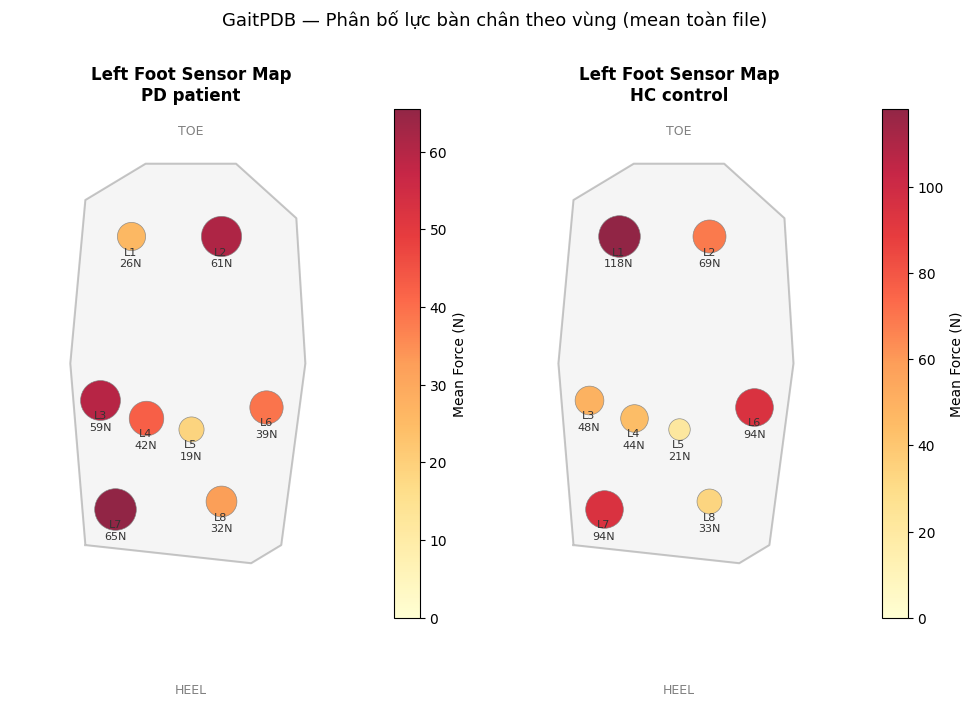

Lưu: ml/data/raw/gaitpdb/sensor_map_comparison.png


In [6]:
# ── Heatmap vị trí sensor trên bàn chân ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 7))

for ax, (label, means) in zip(axes, [('PD patient', means_pd), ('HC control', means_hc)]):
    # Tọa độ (x, y) đại diện vị trí sensor trên bàn chân trái
    # x: 0=medial, 1=lateral | y: 0=toe, 1=heel
    positions = {
        'L1': (0.3, 0.85), 'L2': (0.6, 0.85),   # heel
        'L3': (0.2, 0.40), 'L4': (0.35, 0.35),  # metatarsal 1, 2
        'L5': (0.5,  0.32),                       # metatarsal 3
        'L6': (0.75, 0.38),                       # metatarsal 5
        'L7': (0.25, 0.10), 'L8': (0.6, 0.12),  # toe
    }
    colors = plt.cm.YlOrRd
    max_val = max(means[left_cols])

    # Vẽ outline bàn chân (đơn giản)
    foot_x = [0.15, 0.1, 0.15, 0.35, 0.65, 0.85, 0.88, 0.8, 0.7, 0.15]
    foot_y = [0.0,  0.5, 0.95, 1.05, 1.05, 0.9,  0.5,  0.0, -0.05, 0.0]
    ax.fill(foot_x, foot_y, alpha=0.08, color='gray')
    ax.plot(foot_x, foot_y, 'gray', linewidth=1.5, alpha=0.4)

    for sensor, (x, y) in positions.items():
        val = means[sensor]
        size = 800 * val / max_val + 100
        sc = ax.scatter(x, y, s=size, c=[val], cmap=colors,
                       vmin=0, vmax=max_val, alpha=0.85, edgecolors='gray', linewidths=0.5)
        ax.annotate(f'{sensor}\n{val:.0f}N', (x, y),
                   textcoords='offset points', xytext=(0, -22),
                   ha='center', fontsize=8, color='#333')

    plt.colorbar(sc, ax=ax, label='Mean Force (N)')
    ax.set_title(f'Left Foot Sensor Map\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.2, 1.2)
    ax.axis('off')
    ax.text(0.5, -0.15, 'HEEL', ha='center', fontsize=9, color='gray', transform=ax.transAxes)
    ax.text(0.5,  0.95, 'TOE',  ha='center', fontsize=9, color='gray', transform=ax.transAxes)

plt.suptitle('GaitPDB — Phân bố lực bàn chân theo vùng (mean toàn file)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'sensor_map_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Lưu: ml/data/raw/gaitpdb/sensor_map_comparison.png')

## 3. Visualize Time Series — PD vs Control

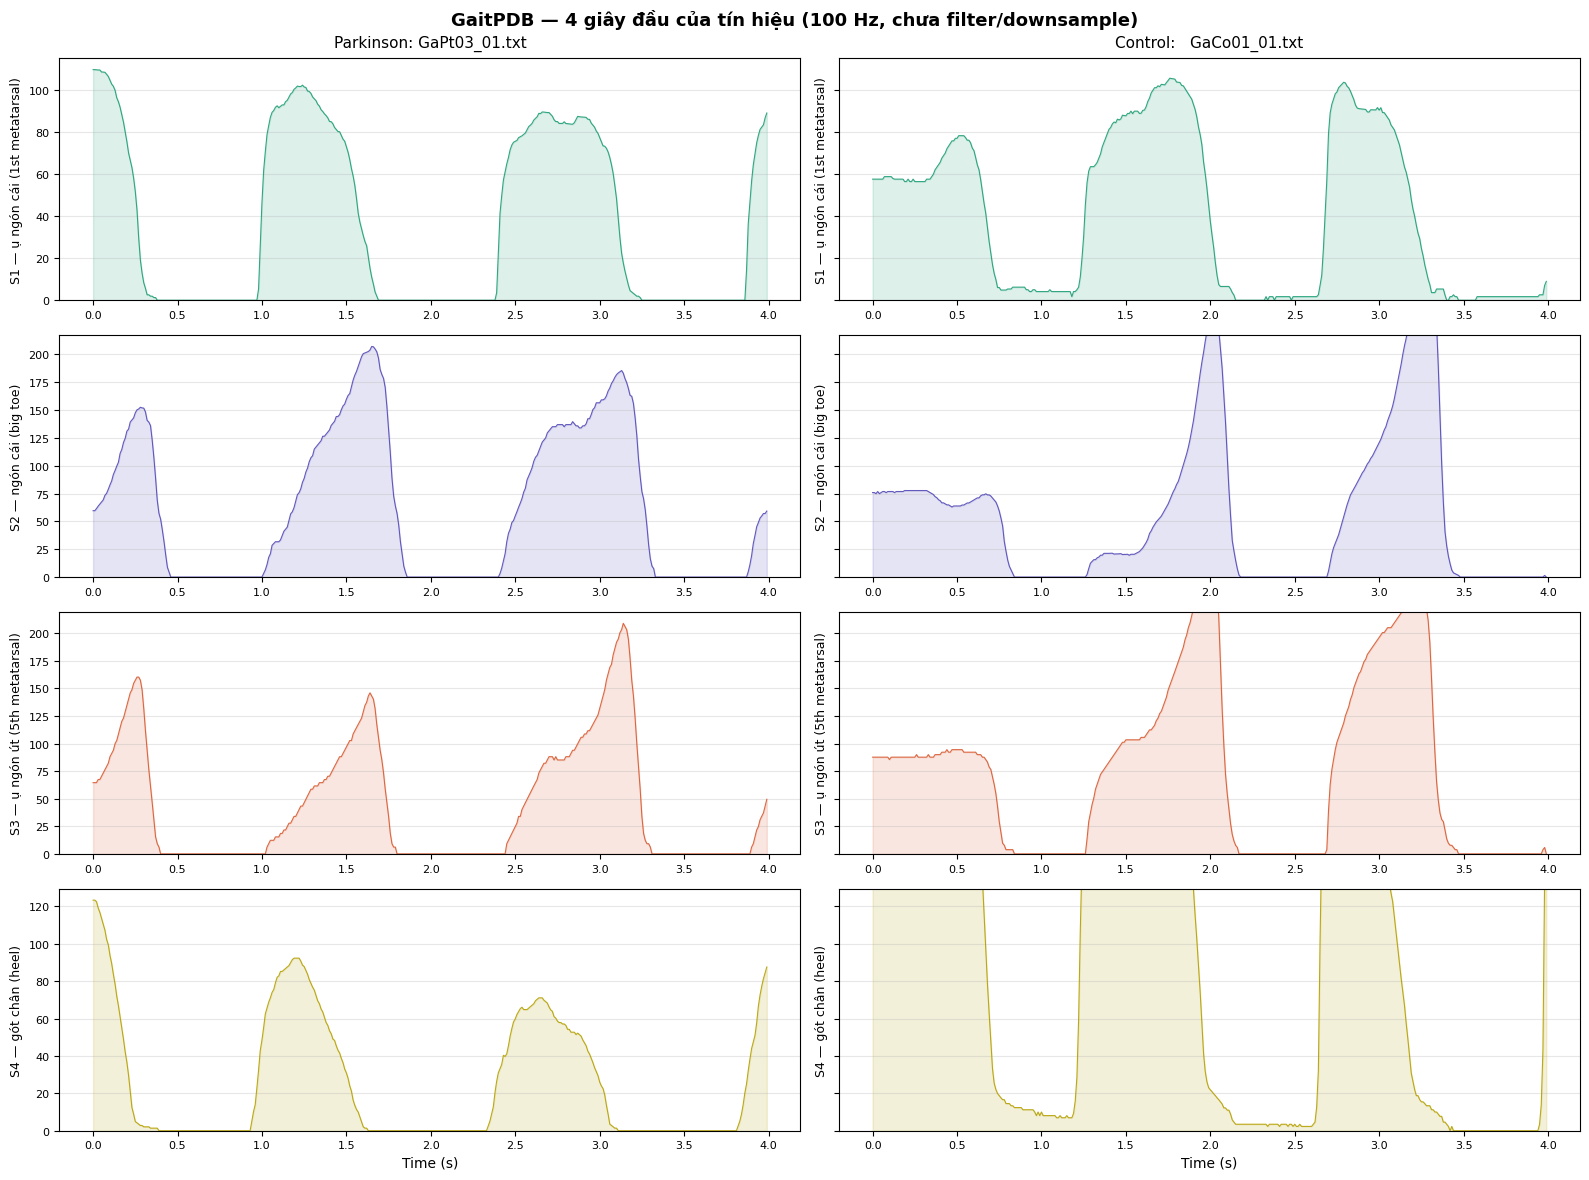

Lưu: ml/data/raw/gaitpdb/timeseries_4ch_comparison.png


In [7]:
# ── Tính 4 kênh đã aggregate (giống hệt preprocess.py) ──────────────────────
def aggregate_to_4ch(df: pd.DataFrame) -> np.ndarray:
    """Replica của preprocess.py::aggregate_gaitpdb_columns() để verify."""
    left = df[['L1','L2','L3','L4','L5','L6','L7','L8']].values.astype(np.float32)
    S1 = (left[:, 2] + left[:, 3]) / 2.0   # metatarsal 1,2 -> ụ ngón cái
    S2 = (left[:, 6] + left[:, 7]) / 2.0   # toe 1,2        -> ngón cái
    S3 =  left[:, 5]                         # metatarsal 5   -> ụ ngón út
    S4 = (left[:, 0] + left[:, 1]) / 2.0   # heel 1,2       -> gót chân
    return np.stack([S1, S2, S3, S4], axis=1)

# Lấy 4 giây đầu (100Hz × 4 = 400 samples)
N_SHOW = 400
time_pd = df_pd['time'].values[:N_SHOW]
time_hc = df_hc['time'].values[:N_SHOW]
sig_pd  = aggregate_to_4ch(df_pd)[:N_SHOW]
sig_hc  = aggregate_to_4ch(df_hc)[:N_SHOW]

SENSOR_LABELS = ['S1 — ụ ngón cái (1st metatarsal)', 'S2 — ngón cái (big toe)',
                 'S3 — ụ ngón út (5th metatarsal)',  'S4 — gót chân (heel)']
COLORS = ['#1D9E75', '#534AB7', '#D85A30', '#B5A000']

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharey='row')
fig.suptitle('GaitPDB — 4 giây đầu của tín hiệu (100 Hz, chưa filter/downsample)',
             fontsize=13, fontweight='bold')

axes[0][0].set_title(f'Parkinson: {sample_pd.name}', fontsize=11, pad=8)
axes[0][1].set_title(f'Control:   {sample_hc.name}', fontsize=11, pad=8)

for i, (label, color) in enumerate(zip(SENSOR_LABELS, COLORS)):
    for col, (t, sig) in enumerate([(time_pd, sig_pd), (time_hc, sig_hc)]):
        ax = axes[i][col]
        ax.plot(t, sig[:, i], color=color, linewidth=0.8, alpha=0.9)
        ax.fill_between(t, 0, sig[:, i], alpha=0.15, color=color)
        ax.set_ylabel(label, fontsize=9)
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(labelsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Time (s)', fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR / 'timeseries_4ch_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Lưu: ml/data/raw/gaitpdb/timeseries_4ch_comparison.png')

## 4. Phổ tần số — kiểm tra tần số cắt 20 Hz có hợp lý không

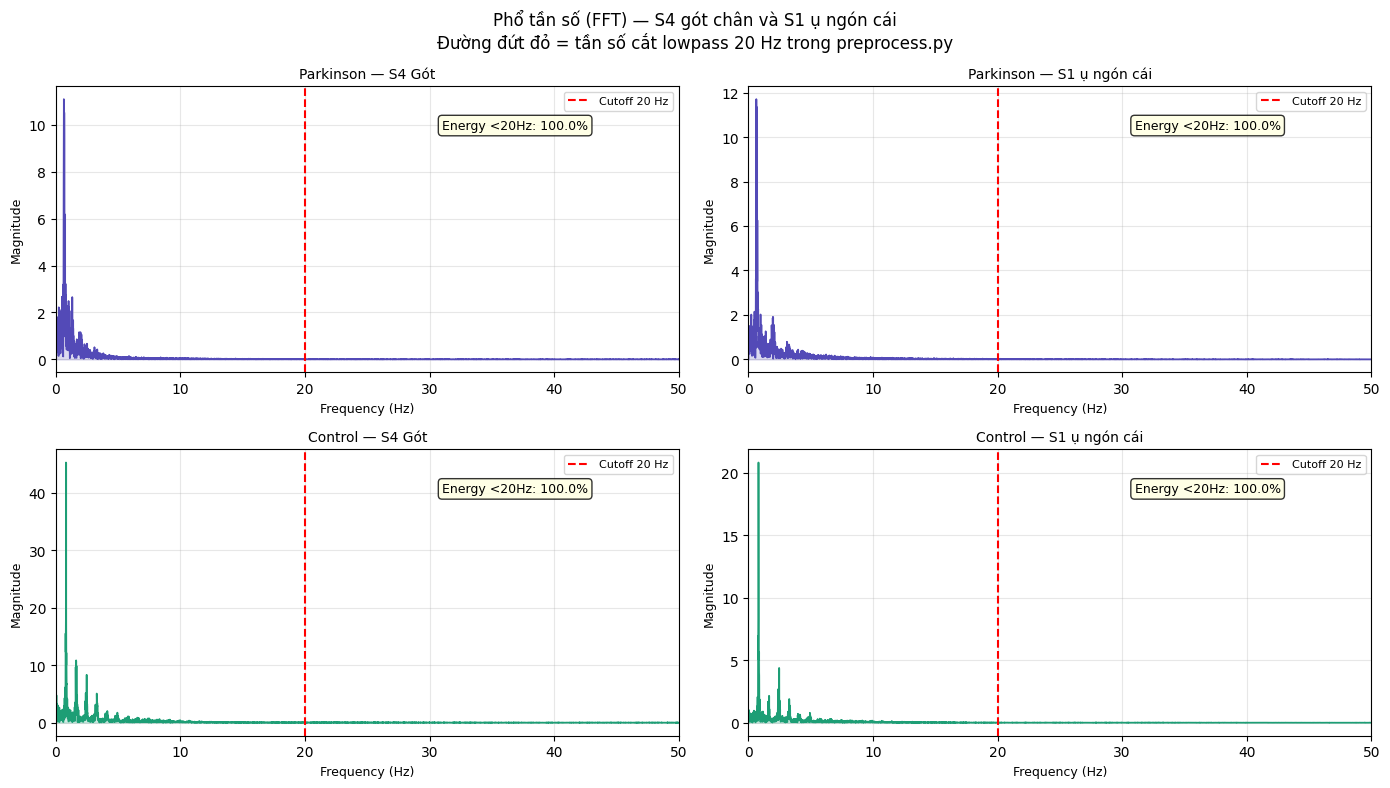

Lưu: ml/data/raw/gaitpdb/fft_analysis.png

✅ Nếu Energy <20Hz > 95% -> tần số cắt 20 Hz trong preprocess.py là hợp lý
⚠️  Nếu <90% -> xem xét tăng LOWPASS_CUTOFF lên 30 Hz


In [8]:
# ── FFT để xem energy tập trung ở tần số nào ─────────────────────────────────
FS = 100  # Hz

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Phổ tần số (FFT) — S4 gót chân và S1 ụ ngón cái\n'
             'Đường đứt đỏ = tần số cắt lowpass 20 Hz trong preprocess.py',
             fontsize=12)

for row, (label, sig, color) in enumerate([
    ('Parkinson', aggregate_to_4ch(df_pd), '#534AB7'),
    ('Control',   aggregate_to_4ch(df_hc), '#1D9E75'),
]):
    for col, (ch_idx, ch_name) in enumerate([(3, 'S4 Gót'), (0, 'S1 ụ ngón cái')]):
        ax = axes[row][col]
        signal = sig[:, ch_idx]
        n = len(signal)
        fft_mag = np.abs(np.fft.rfft(signal - signal.mean())) / n
        freqs   = np.fft.rfftfreq(n, d=1/FS)

        # Chỉ show 0–50 Hz (Nyquist)
        mask = freqs <= 50
        ax.plot(freqs[mask], fft_mag[mask], color=color, linewidth=1.2)
        ax.fill_between(freqs[mask], 0, fft_mag[mask], alpha=0.2, color=color)
        ax.axvline(20, color='red', linestyle='--', linewidth=1.5, label='Cutoff 20 Hz')

        # Tính % energy dưới 20Hz
        mask_low  = freqs <= 20
        energy_low  = np.sum(fft_mag[mask_low]**2)
        energy_total = np.sum(fft_mag[mask]**2)
        pct = 100 * energy_low / (energy_total + 1e-10)

        ax.set_title(f'{label} — {ch_name}', fontsize=10)
        ax.set_xlabel('Frequency (Hz)', fontsize=9)
        ax.set_ylabel('Magnitude', fontsize=9)
        ax.text(0.62, 0.85, f'Energy <20Hz: {pct:.1f}%',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 50)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fft_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Lưu: ml/data/raw/gaitpdb/fft_analysis.png')
print()
print('✅ Nếu Energy <20Hz > 95% -> tần số cắt 20 Hz trong preprocess.py là hợp lý')
print('⚠️  Nếu <90% -> xem xét tăng LOWPASS_CUTOFF lên 30 Hz')

## 5. Kiểm tra chất lượng toàn bộ dataset

In [9]:
# ── Scan toàn bộ file, phát hiện vấn đề trước khi chạy preprocess.py ────────
WINDOW_SIZE = 100   # phải khớp với preprocess.py

results = []

for group, files, label in [('PD', pd_files, 1), ('HC', hc_files, 0)]:
    for fpath in files:
        try:
            df = pd.read_csv(fpath, sep='\t', header=None, engine='python')
            df_clean = df.dropna()

            n_raw    = len(df)
            n_clean  = len(df_clean)
            n_cols   = df.shape[1]
            duration = float(df_clean.iloc[-1, 0]) if n_clean > 0 else 0
            sr_est   = n_clean / duration if duration > 0 else 0

            # Tính số window sẽ tạo ra (stride=50)
            # Sau downsample 100->50Hz, độ dài giảm /2
            n_after_ds  = n_clean // 2
            n_windows   = max(0, (n_after_ds - WINDOW_SIZE) // 50 + 1)

            # Aggregate 4 channel để check range
            df_clean.columns = range(df_clean.shape[1])
            left = df_clean.iloc[:, 1:9].values.astype(np.float32)
            S4 = (left[:, 0] + left[:, 1]) / 2.0   # heel

            issues = []
            if n_cols != 19:             issues.append(f'cols={n_cols}≠19')
            if n_clean < WINDOW_SIZE*2:  issues.append(f'quá ngắn ({n_clean} rows)')
            if n_raw - n_clean > 10:     issues.append(f'{n_raw-n_clean} NaN rows')
            if S4.max() < 1.0:           issues.append('heel≈0 (sensor lỗi?)')
            if abs(sr_est - 100) > 5:    issues.append(f'SR≈{sr_est:.0f}Hz≠100')

            results.append({
                'file':      fpath.name,
                'group':     group,
                'rows':      n_clean,
                'cols':      n_cols,
                'duration_s': round(duration, 1),
                'sr_hz':     round(sr_est, 1),
                'n_windows': n_windows,
                'heel_max':  round(float(S4.max()), 1),
                'issues':    ', '.join(issues) if issues else '—',
            })
        except Exception as e:
            results.append({
                'file': fpath.name, 'group': group,
                'rows': 0, 'cols': 0, 'duration_s': 0,
                'sr_hz': 0, 'n_windows': 0, 'heel_max': 0,
                'issues': f'READ ERROR: {e}'
            })

df_qc = pd.DataFrame(results)

# Tóm tắt
n_ok   = (df_qc['issues'] == '—').sum()
n_warn = (df_qc['issues'] != '—').sum()
print(f'Tổng file    : {len(df_qc)}')
print(f'  ✅ OK      : {n_ok}')
print(f'  ⚠️  Cần xem : {n_warn}')
print(f'Windows ước tính: PD={df_qc[df_qc.group=="PD"]["n_windows"].sum():,}  |  HC={df_qc[df_qc.group=="HC"]["n_windows"].sum():,}')
print()

# Hiển thị file có vấn đề
problems = df_qc[df_qc['issues'] != '—']
if len(problems) > 0:
    print('File có vấn đề:')
    display(problems[['file','group','rows','cols','issues']])
else:
    print('✅ Không có file nào cần xử lý đặc biệt')

Tổng file    : 306
  ✅ OK      : 306
  ⚠️  Cần xem : 0
Windows ước tính: PD=22,762  |  HC=10,011

✅ Không có file nào cần xử lý đặc biệt


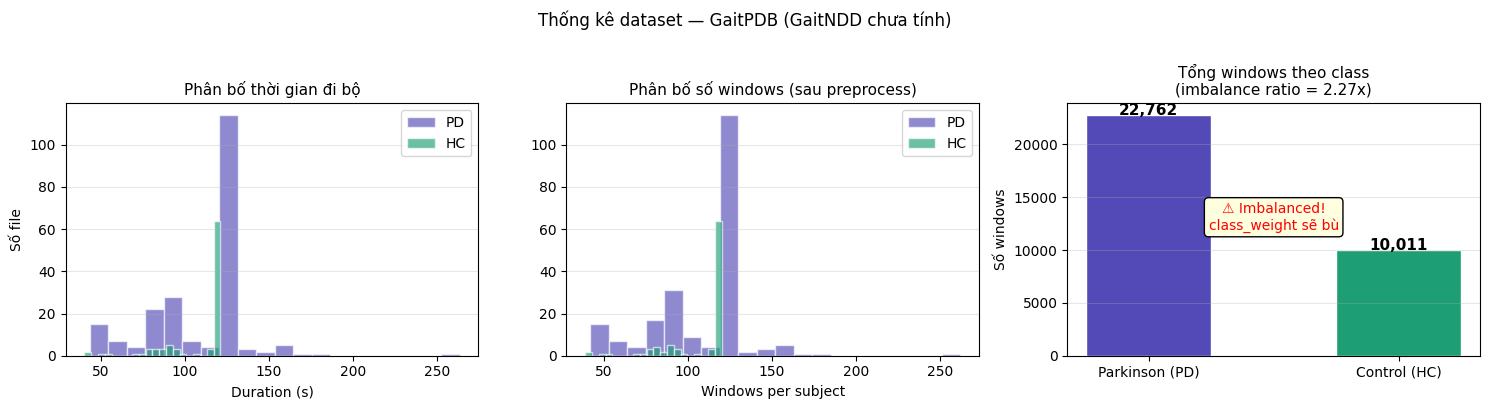

In [10]:
# ── Phân bố thời gian đi bộ mỗi subject ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Duration
for grp, color in [('PD', '#534AB7'), ('HC', '#1D9E75')]:
    axes[0].hist(df_qc[df_qc.group==grp]['duration_s'], bins=20,
                alpha=0.65, color=color, label=grp, edgecolor='white')
axes[0].set_xlabel('Duration (s)', fontsize=10)
axes[0].set_ylabel('Số file', fontsize=10)
axes[0].set_title('Phân bố thời gian đi bộ', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Windows per subject
for grp, color in [('PD', '#534AB7'), ('HC', '#1D9E75')]:
    axes[1].hist(df_qc[df_qc.group==grp]['n_windows'], bins=20,
                alpha=0.65, color=color, label=grp, edgecolor='white')
axes[1].set_xlabel('Windows per subject', fontsize=10)
axes[1].set_title('Phân bố số windows (sau preprocess)', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Tổng windows theo class
total_pd = df_qc[df_qc.group=='PD']['n_windows'].sum()
total_hc = df_qc[df_qc.group=='HC']['n_windows'].sum()
bars = axes[2].bar(['Parkinson (PD)', 'Control (HC)'], [total_pd, total_hc],
                   color=['#534AB7', '#1D9E75'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [total_pd, total_hc]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')

ratio = total_pd / total_hc
axes[2].set_title(f'Tổng windows theo class\n(imbalance ratio = {ratio:.2f}x)', fontsize=11)
axes[2].set_ylabel('Số windows', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)
if ratio > 1.5 or ratio < 0.67:
    axes[2].text(0.5, 0.5, f'⚠️ Imbalanced!\nclass_weight sẽ bù',
                transform=axes[2].transAxes, ha='center', fontsize=10,
                color='red', bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.suptitle('Thống kê dataset — GaitPDB (GaitNDD chưa tính)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'dataset_statistics.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. So sánh gait pattern đặc trưng PD vs HC

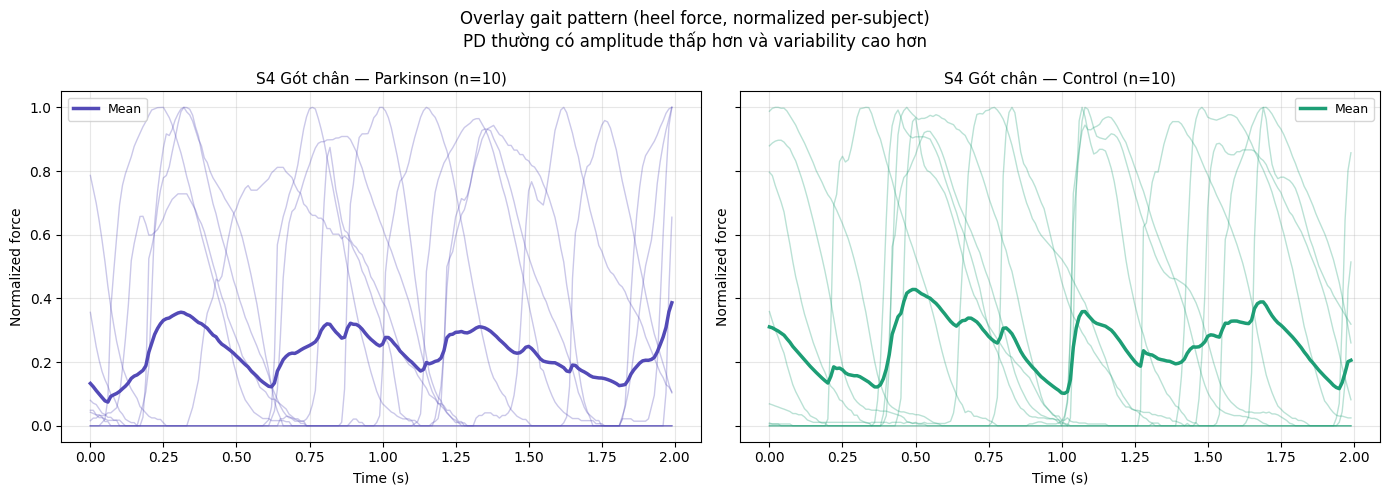

In [11]:
# ── Butterfly plot: 10 subject PD vs 10 HC trên cùng trục ───────────────────
# Normalize per-subject -> [0,1] rồi overlay để thấy variability
N_EACH    = min(10, len(pd_files), len(hc_files))
SEG_START = 200   # bỏ qua 2 giây đầu (startup)
SEG_LEN   = 200   # lấy 2 giây (200 samples @ 100Hz)

def get_normalized_segment(fpath: Path) -> np.ndarray | None:
    try:
        df = pd.read_csv(fpath, sep='\t', header=None, engine='python').dropna()
        if len(df) < SEG_START + SEG_LEN:
            return None
        df.columns = range(df.shape[1])
        left = df.iloc[SEG_START:SEG_START+SEG_LEN, 1:9].values.astype(np.float32)
        S4 = (left[:, 0] + left[:, 1]) / 2.0  # gót
        col_max = S4.max()
        if col_max < 1.0: return None
        return S4 / (col_max + 1e-8)
    except:
        return None

segs_pd = [s for f in pd_files[:N_EACH*2] if (s := get_normalized_segment(f)) is not None][:N_EACH]
segs_hc = [s for f in hc_files[:N_EACH*2] if (s := get_normalized_segment(f)) is not None][:N_EACH]

t = np.arange(SEG_LEN) / 100.0  # giây

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, segs, color, title in [
    (axes[0], segs_pd, '#534AB7', f'Parkinson (n={len(segs_pd)})'),
    (axes[1], segs_hc, '#1D9E75', f'Control (n={len(segs_hc)})'),
]:
    for seg in segs:
        ax.plot(t, seg, color=color, alpha=0.3, linewidth=1.0)
    if segs:
        mean_seg = np.mean(segs, axis=0)
        ax.plot(t, mean_seg, color=color, linewidth=2.5, label='Mean')
    ax.set_title(f'S4 Gót chân — {title}', fontsize=11)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Normalized force', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Overlay gait pattern (heel force, normalized per-subject)\n'
             'PD thường có amplitude thấp hơn và variability cao hơn',
             fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'gait_pattern_overlay.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Tóm tắt — Checklist trước khi chạy preprocess.py

In [12]:
# ── Checklist tổng kết ────────────────────────────────────────────────────────
print('=' * 60)
print('  CHECKLIST TRƯỚC KHI CHẠY preprocess.py')
print('=' * 60)

checks = []

# 1. File tồn tại
ok1 = len(pd_files) > 0 and len(hc_files) > 0
checks.append(('Dataset tải xong', ok1, f'{len(pd_files)} PD + {len(hc_files)} HC files'))

# 2. Cột đúng 19
ok2 = (df_qc['cols'] == 19).all()
checks.append(('Tất cả file có 19 cột', ok2,
               'OK' if ok2 else f"{(df_qc['cols']!=19).sum()} file sai cột"))

# 3. Không có file lỗi
ok3 = n_warn == 0
checks.append(('Không có file bị lỗi', ok3,
               'OK' if ok3 else f'{n_warn} file cần xem lại (xem phần 5)'))

# 4. Sample rate đúng
ok4 = ((df_qc['sr_hz'] - 100).abs() < 5).all()
checks.append(('Sample rate ≈ 100 Hz', ok4,
               'OK' if ok4 else 'Một số file có SR bất thường'))

# 5. Đủ windows
total_w = df_qc['n_windows'].sum()
ok5 = total_w >= 500
checks.append(('Đủ dữ liệu train (≥500 windows)', ok5, f'Ước tính: {total_w:,} windows'))

for name, ok, detail in checks:
    icon = '✅' if ok else '❌'
    print(f'  {icon}  {name:<38}  {detail}')

print('=' * 60)
all_ok = all(ok for _, ok, _ in checks)
if all_ok:
    print()
    print('  🚀 Sẵn sàng! Chạy tiếp:')
    print('     python ml/src/preprocess.py')
    print('     (hoặc mở notebook 02_preprocess.ipynb)')
else:
    print()
    print('  ⚠️  Giải quyết các lỗi ❌ trước khi chạy preprocess.py')

  CHECKLIST TRƯỚC KHI CHẠY preprocess.py
  ✅  Dataset tải xong                        214 PD + 92 HC files
  ✅  Tất cả file có 19 cột                   OK
  ✅  Không có file bị lỗi                    OK
  ✅  Sample rate ≈ 100 Hz                    OK
  ✅  Đủ dữ liệu train (≥500 windows)         Ước tính: 32,773 windows

  🚀 Sẵn sàng! Chạy tiếp:
     python ml/src/preprocess.py
     (hoặc mở notebook 02_preprocess.ipynb)
